# New Jupyter Notebook



Deep Tree Accuracy: 1.0
Shallow Tree Accuracy: 1.0


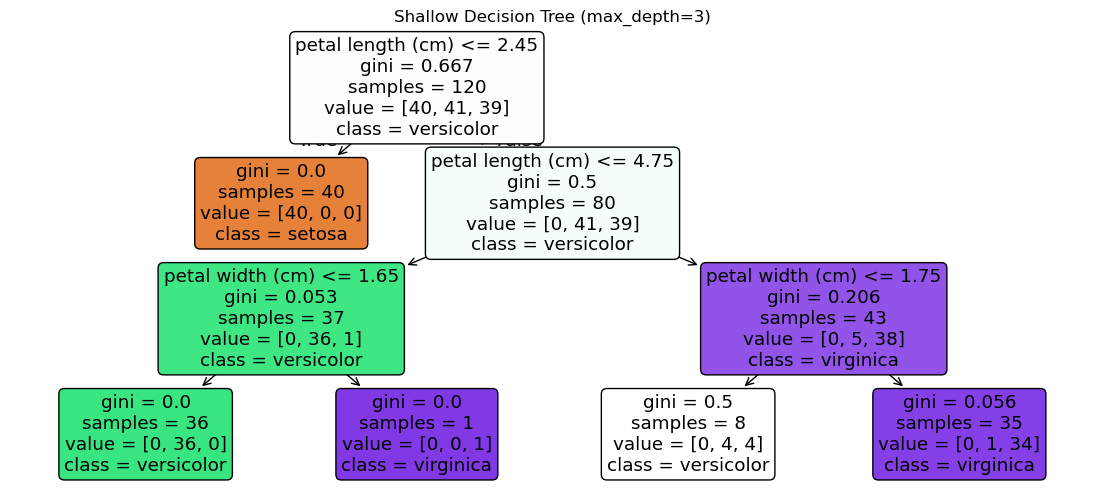

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.75
|   |   |--- petal width (cm) <= 1.65
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.65
|   |   |   |--- class: 2
|   |--- petal length (cm) >  4.75
|   |   |--- petal width (cm) <= 1.75
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.75
|   |   |   |--- class: 2



In [6]:
#Decision Tree Classifier on Iris Dataset
#import the necessary libraries
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier , export_text, plot_tree
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score 
import matplotlib.pyplot as plt 

#load data 
data = load_iris()
X,y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

#train the deep tree
deep_tree = DecisionTreeClassifier(max_depth=None, random_state=42)
deep_tree.fit(X_train, y_train)
print("Deep Tree Accuracy:", accuracy_score(y_test, deep_tree.predict(X_test)))

#train the shallow tree
shallow_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
shallow_tree.fit(X_train, y_train)
print("Shallow Tree Accuracy:", accuracy_score(y_test, shallow_tree.predict(X_test)))

#visualize the shallow trees
plt.figure(figsize=(14,6))
plot_tree(shallow_tree, feature_names=data.feature_names, class_names=data.target_names, filled=True, rounded=True)
plt.title("Shallow Decision Tree (max_depth=3)")
plt.show()

#print the rules as text 
print(export_text(shallow_tree, feature_names=list(data.feature_names)))


Random Forest Accuracy: 1.0


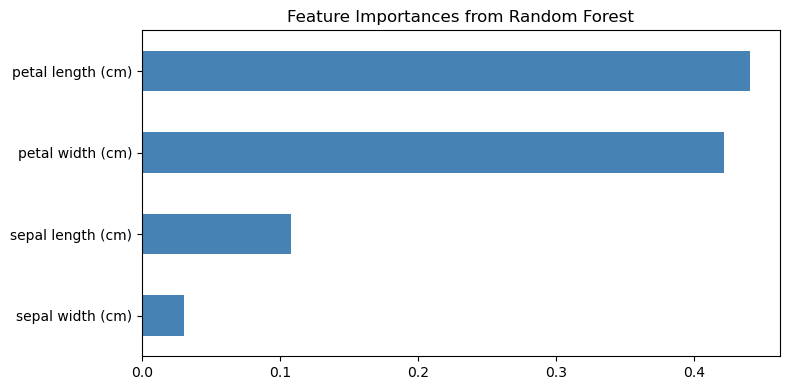


Single tree: 1.000
Random Forest: 1.000


In [7]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd 
import seaborn as sns 

#train a random forest
rf = RandomForestClassifier (n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("Random Forest Accuracy:", accuracy_score(y_test, rf.predict(X_test)))

#feature importance
importances = pd.Series(rf.feature_importances_, index=data.feature_names)
importances.sort_values().plot(kind='barh', color='steelblue', figsize=(8,4))
plt.title("Feature Importances from Random Forest")
plt.tight_layout()
plt.show()

#compare : single tree vs forest
print(f"\nSingle tree: {accuracy_score(y_test,shallow_tree.predict(X_test)):.3f}")
print(f"Random Forest: {accuracy_score(y_test, rf.predict(X_test)):.3f}")

                     Test Accuracy  CV F1 Mean  CV F1 Std
Logistic Regression         0.9737      0.9792     0.0141
Decision Tree               0.9474      0.9411     0.0185
Random Forest               0.9649      0.9671     0.0137


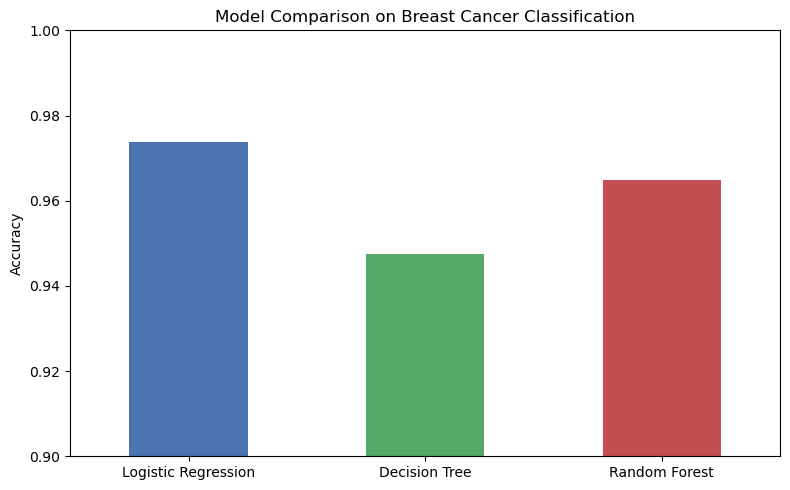

In [10]:
#importing the necessary libraries for breast cancer dataset
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import pandas as pd 
import matplotlib.pyplot as plt

#setup the breast cancer dataset
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

#train all models 
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    cv_scores = cross_val_score(model, X_train_s, y_train, cv=5, scoring='f1')
    results[name] = {
        "Test Accuracy": model.score(X_test_s, y_test),
        "CV F1 Mean": cv_scores.mean(),
        "CV F1 Std": cv_scores.std()
    }
    
#clean comparison table 
df_results = pd.DataFrame(results).T.round(4)
print(df_results)

#bar chart for the README
df_results["Test Accuracy"].plot(kind='bar', color=['#4C72B0', '#55A868', '#C44E52'], figsize=(8,5), rot=0)
plt.title("Model Comparison on Breast Cancer Classification")
plt.ylabel("Accuracy")
plt.ylim(0.9, 1.0)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()